In [70]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [71]:
print(sns.get_dataset_names())

['anagrams', 'anscombe', 'attention', 'brain_networks', 'car_crashes', 'diamonds', 'dots', 'dowjones', 'exercise', 'flights', 'fmri', 'geyser', 'glue', 'healthexp', 'iris', 'mpg', 'penguins', 'planets', 'seaice', 'taxis', 'tips', 'titanic']


In [72]:
df = sns.load_dataset("dots")

In [73]:
df.head()

,align,choice,time,coherence,firing_rate
0,dots,T1,-80,0.0,33.189967
1,dots,T1,-80,3.2,31.691726
2,dots,T1,-80,6.4,34.279840
3,dots,T1,-80,12.8,32.631874
4,dots,T1,-80,25.6,35.060487


In [74]:
df.shape

(848, 5)

In [75]:
df.isnull().sum()

align          0
choice         0
time           0
coherence      0
firing_rate    0
dtype: int64

In [76]:
from sklearn.preprocessing import LabelEncoder

# LabelEncoder define aur apply karein
le = LabelEncoder()
df['choice_encoded'] = le.fit_transform(df['choice'])

In [77]:
df = df.drop(columns=['choice'])
df.head()

,align,time,coherence,firing_rate,choice_encoded
0,dots,-80,0.0,33.189967,0
1,dots,-80,3.2,31.691726,0
2,dots,-80,6.4,34.279840,0
3,dots,-80,12.8,32.631874,0
4,dots,-80,25.6,35.060487,0


In [78]:
x = df['align']
df = df.drop(columns=['align'])
df.head()

,time,coherence,firing_rate,choice_encoded
0,-80,0.0,33.189967,0
1,-80,3.2,31.691726,0
2,-80,6.4,34.279840,0
3,-80,12.8,32.631874,0
4,-80,25.6,35.060487,0


In [79]:
from sklearn.cluster import KMeans
kmean = KMeans(n_clusters=3)

In [80]:
label = kmean.fit_predict(df)
df['cluster'] = label
df.head()

,time,coherence,firing_rate,choice_encoded,cluster
0,-80,0.0,33.189967,0,0
1,-80,3.2,31.691726,0,0
2,-80,6.4,34.279840,0,0
3,-80,12.8,32.631874,0,0
4,-80,25.6,35.060487,0,0


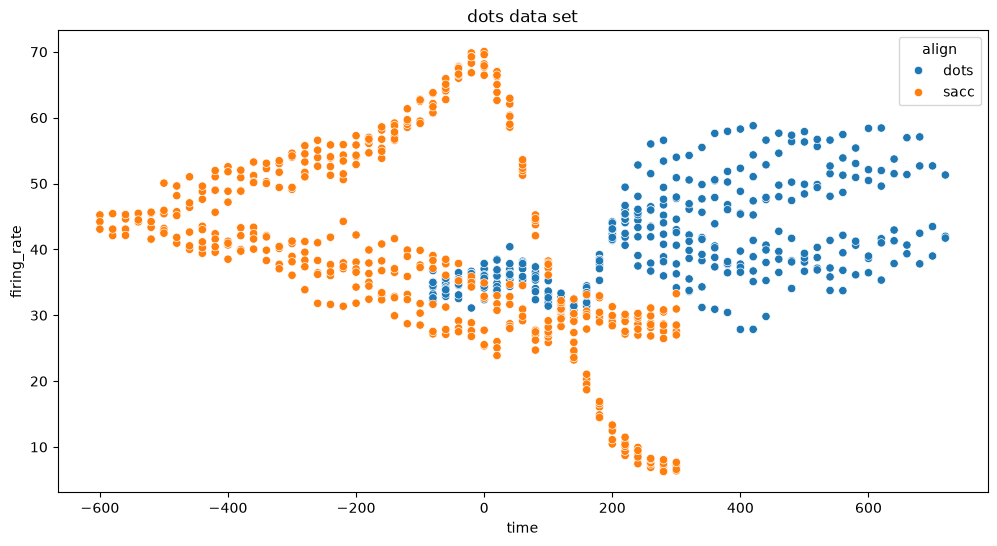

In [81]:
plt.figure(figsize=(12,6))
sns.scatterplot(x= 'time',y= 'firing_rate', data= df , hue= x,palette='tab10')
plt.title('dots data set')
plt.show()

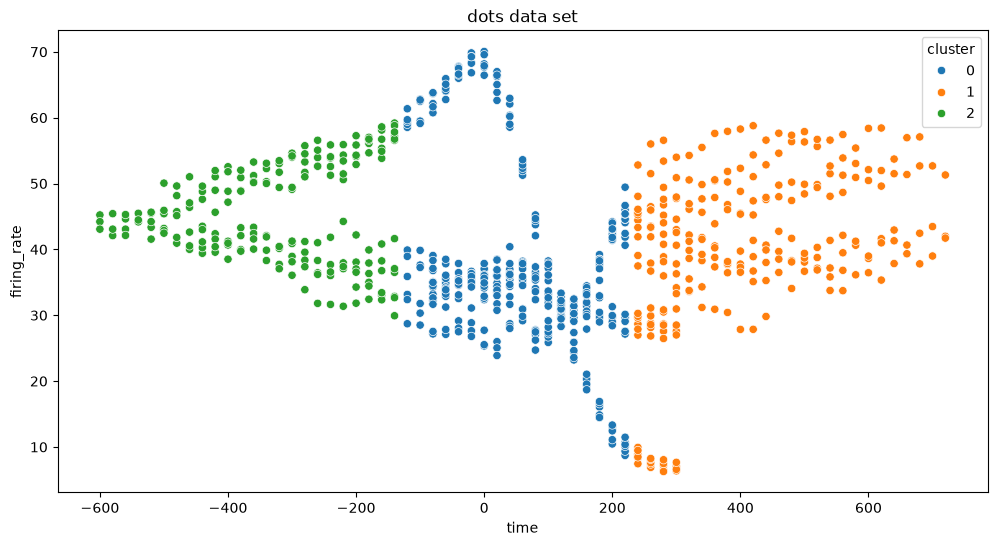

In [82]:
plt.figure(figsize=(12,6))
sns.scatterplot(x= 'time',y= 'firing_rate', data= df , hue= 'cluster',palette='tab10')
plt.title('dots data set')
plt.show()

In [83]:
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)
df['dbscan_cluster'] = dbscan.fit_predict(df)

In [84]:
df.head()

,time,coherence,firing_rate,choice_encoded,cluster,dbscan_cluster
0,-80,0.0,33.189967,0,0,-1
1,-80,3.2,31.691726,0,0,-1
2,-80,6.4,34.279840,0,0,-1
3,-80,12.8,32.631874,0,0,-1
4,-80,25.6,35.060487,0,0,-1


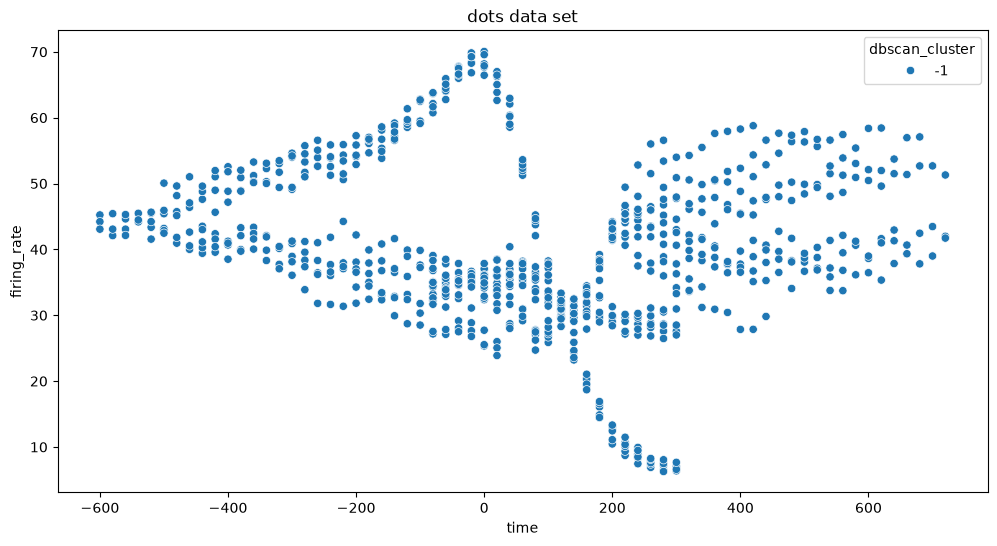

In [85]:
plt.figure(figsize=(12,6))
sns.scatterplot(x= '',y= 'firing_rate', data= df , hue= 'dbscan_cluster',palette='tab10')
plt.title('dots data set')
plt.show()